# Lab 6: Logistic Regression & KNN Classification

Name: Nainsy chawla

Roll Number: 023-24-0261

Section: H

GitHub Repository: https://github.com/Nainsy-chawla/ML_Lab_Practise

Kaggle profile : https://www.kaggle.com/nainsychawla

Dataset source:https://www.kaggle.com/code/emineyetm/telco-customer-churn

Dataset : telco customer churn

# Problem Definition & Dataset Verification

In [54]:
#Task 1
import pandas as pd
df = pd.read_csv('clean_churn.csv')
print(df.shape)
print(df.info())

(7010, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7010 entries, 0 to 7009
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   str    
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   str    
 3   Dependents        7010 non-null   str    
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   str    
 6   MultipleLines     7010 non-null   str    
 7   InternetService   7010 non-null   str    
 8   OnlineSecurity    7010 non-null   str    
 9   OnlineBackup      7010 non-null   str    
 10  DeviceProtection  7010 non-null   str    
 11  TechSupport       7010 non-null   str    
 12  StreamingTV       7010 non-null   str    
 13  StreamingMovies   7010 non-null   str    
 14  Contract          7010 non-null   str    
 15  PaperlessBilling  7010 non-null   str    
 16  PaymentMethod     7010 non-null   str    


Explanation: The cleaned dataset has 7010 rows and 20 columns. There are no missing values, and the dataset contains both categorical and numerical columns. The Churn column is our target variable.

*Task 2*

Explanation: The Decision Tree achieved an accuracy of 79.32%, precision of 63.11%, recall of 52.56%, and F1-score of 57.35% on the test set. The tuned Random Forest achieved an accuracy of 80.10%, precision of 66.67%, recall of 49.60%, and F1-score of 56.88%. These results will be used as benchmarks for comparing Logistic Regression and KNN.

# Feature Scaling & Preparation

In [55]:
#Task 3
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'No': 0, 'Yes': 1})
X = pd.get_dummies(X, drop_first=True)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7010, 30)
y shape: (7010,)


Explanation: 
I separated Churn from the input features and converted No to 0 and Yes to 1. I also converted the categorical columns into numerical dummy variables, giving me 30 input features.

*Task 4*

Explanation: Feature scaling is important for KNN because KNN uses distance calculations, and features with larger numerical ranges can dominate the distance. Logistic Regression also benefits from standardized features, while Decision Trees and Random Forests do not require scaling because their decisions are based on feature splits rather than distance calculations.

In [56]:
#Task 5
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Explanation:
 The scaler is fitted only on the training data to prevent data leakage. The same learned scaling parameters are then applied to the test data so that the test set remains unseen during model training.

# Logistic Regression

In [57]:
#Task 6
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()

logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)

EXplanation: I trained the Logistic Regression model using the scaled training data and then used it to predict whether the customers in the test set would churn or not.

In [58]:
#Task 7
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1-score :", f1_lr)

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("\nConfusion Matrix:")
print(cm_lr)

Accuracy : 0.8088445078459344
Precision: 0.6734006734006734
Recall   : 0.5390835579514824
F1-score : 0.5988023952095808

Confusion Matrix:
[[934  97]
 [171 200]]


Explanation: The Logistic Regression model achieved 80.88% accuracy, 67.34% precision, 53.91% recall, and 59.88% F1-score. From the confusion matrix, the model correctly predicted 934 non-churn customers and 200 churn customers, while 171 churn customers were incorrectly predicted as non-churn.

In [59]:
#Task 8
probabilities = logreg.predict_proba(X_test_scaled[:5])

print(probabilities)

[[0.63572458 0.36427542]
 [0.98649512 0.01350488]
 [0.91238377 0.08761623]
 [0.69873783 0.30126217]
 [0.74747026 0.25252974]]


Explanation: predict_proba() shows the probability of a customer belonging to each class. For example, in the first prediction, the probability of No Churn is 0.636 and Churn is 0.364, so predict() classifies this customer as No Churn.

# KNN & Choosing K 

In [60]:
#Task 9
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

k_values = [1, 3, 5, 7, 9, 11, 15, 21]

knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred_knn = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred_knn)
    f1 = f1_score(y_test, y_pred_knn)

    knn_results.append([k, accuracy, f1])

knn_results_df = pd.DataFrame(
    knn_results,
    columns=['K', 'Accuracy', 'F1']
)

print(knn_results_df)

    K  Accuracy        F1
0   1  0.707561  0.459103
1   3  0.736805  0.488211
2   5  0.748930  0.505618
3   7  0.762482  0.523605
4   9  0.769615  0.540541
5  11  0.771041  0.549790
6  15  0.784593  0.566092
7  21  0.780314  0.560000


Explanation: I tested K values from 1 to 21. The F1-score increased from 0.4591 at K=1 to 0.5661 at K=15, but then decreased slightly to 0.5600 at K=21.

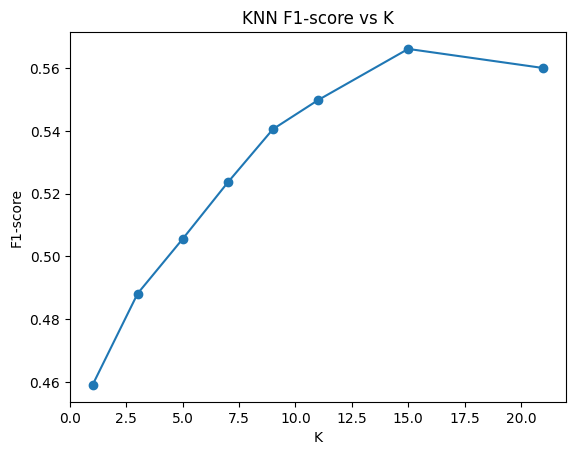

In [61]:
#Task 10
import matplotlib.pyplot as plt

plt.plot(
    knn_results_df['K'],
    knn_results_df['F1'],
    marker='o'
)

plt.xlabel('K')
plt.ylabel('F1-score')
plt.title('KNN F1-score vs K')
plt.show()

Explanation: I selected K = 15 because it gave the highest F1-score of 0.5661 among the tested values. I did not choose the smallest or largest K because their F1-scores were lower than the result at K=15.

In [62]:
#Task 11
knn_final = KNeighborsClassifier(n_neighbors=15)

knn_final.fit(X_train_scaled, y_train)

y_pred_knn = knn_final.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("Accuracy :", accuracy_knn)
print("Precision:", precision_knn)
print("Recall   :", recall_knn)
print("F1-score :", f1_knn)

cm_knn = confusion_matrix(y_test, y_pred_knn)

print("\nConfusion Matrix:")
print(cm_knn)

Accuracy : 0.7845934379457917
Precision: 0.6061538461538462
Recall   : 0.5309973045822103
F1-score : 0.5660919540229885

Confusion Matrix:
[[903 128]
 [174 197]]


Explanation: With K = 15, the KNN model achieved 78.46% accuracy, 60.62% precision, 53.10% recall, and 56.61% F1-score. The confusion matrix shows that the model correctly predicted 903 non-churn customers and 197 churn customers, while 128 non-churn customers were predicted as churn and 174 churn customers were missed.

# Model Comparison (4 Models)

In [63]:
#Task 12
comparison = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Random Forest',
        'Logistic Regression',
        'KNN'
    ],
    'Accuracy': [
        0.793153,
        0.800999,
        accuracy_lr,
        accuracy_knn
    ],
    'Precision': [
        0.631068,
        0.666667,
        precision_lr,
        precision_knn
    ],
    'Recall': [
        0.525606,
        0.495957,
        recall_lr,
        recall_knn
    ],
    'F1-score': [
        0.573529,
        0.568779,
        f1_lr,
        f1_knn
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.793153,0.631068,0.525606,0.573529
1,Random Forest,0.800999,0.666667,0.495957,0.568779
2,Logistic Regression,0.808845,0.673401,0.539084,0.598802
3,KNN,0.784593,0.606154,0.530997,0.566092


Explanation: Logistic Regression has the highest accuracy (80.88%), precision (67.34%), and F1-score (59.88%) among the four models. Random Forest has slightly higher accuracy than the Decision Tree, while KNN has the lowest accuracy and F1-score among the four models.

*Task 13*
    
Explanation: Logistic Regression gives the highest accuracy, precision, and F1-score, while Logistic Regression also has the highest recall among the four models. Because the dataset has more non-churn customers than churn customers, accuracy alone is not enough to compare the models. Recall and F1-score are important because they show how well the models identify customers who actually churn, so I would give more attention to these metrics along with precision.

# Coefficient Interpretation 

In [64]:
# Task 14
import numpy as np

coefficients = logreg.coef_[0]

coef_table = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients,
    'Odds Ratio': np.exp(coefficients)
})

coef_table['Absolute Coefficient'] = abs(coef_table['Coefficient'])

coef_table = coef_table.sort_values(
    'Absolute Coefficient',
    ascending=False
)

coef_table
coef_table.head(10)

,Feature,Coefficient,Odds Ratio,Absolute Coefficient
1,tenure,-1.417202,0.242391,1.417202
3,TotalCharges,0.726308,2.067434,0.726308
25,Contract_Two year,-0.571146,0.564878,0.571146
10,InternetService_Fiber optic,0.517509,1.677843,0.517509
2,MonthlyCharges,-0.330064,0.718878,0.330064
24,Contract_One year,-0.279345,0.756279,0.279345
26,PaperlessBilling_Yes,0.184816,1.202997,0.184816
9,MultipleLines_Yes,0.154627,1.167222,0.154627
28,PaymentMethod_Electronic check,0.149189,1.160892,0.149189
19,TechSupport_Yes,-0.142096,0.867538,0.142096


Explanation:The largest coefficient in absolute value is tenure, with a coefficient of -1.4172 and an odds ratio of 0.2424. Since the numerical features were standardized, this represents the effect of a one-standard-deviation increase in tenure, with lower odds of churn when the other features are held constant. TotalCharges has an odds ratio of 2.0674, so a one-standard-deviation increase in TotalCharges is associated with about 2.07 times the odds of churn. Contract_Two year has an odds ratio of 0.5649, indicating lower odds of churn compared with the reference contract category. InternetService_Fiber optic has an odds ratio of 1.6778, indicating higher odds of churn compared with its reference category.

*Task 15*
    
Explanation:
The Logistic Regression results agree with the earlier labs because tenure, InternetService_Fiber optic, and TotalCharges were also important features in the Decision Tree results. The main difference is that Logistic Regression also shows a relatively large effect for Contract_Two year, while the Decision Tree's feature importance ranked other features differently. This difference is expected because the two models measure feature importance in different ways.


# 7 — Final Model Selection & Conclusion 

*Task 16*

Explanation: I selected Logistic Regression as my final model because it achieved the highest accuracy (80.88%), precision (67.34%), recall (53.91%), and F1-score (59.88%) in the comparison table. However, I would not rely only on these test-set results because Lab 4 showed that a single split can give a limited view of model performance, so cross-validation should also be considered before using the model on new data.

*Task 17*

Conclusion:

Explanation: Logistic Regression performed best on the test set, with the highest accuracy and F1-score among the four models. Its F1-score improved from the Decision Tree's 57.35% to 59.88%. Feature scaling was important for Logistic Regression and KNN, especially because KNN uses distance calculations. KNN performed lower than the other models, with an F1-score of 56.61%. The main limitation is the class imbalance, which can cause some churn customers to be missed. Cross-validation and further feature tuning could be used to improve and more reliably evaluate the model.
